In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\icons\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [3]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\icons\AppData\Local\Programs\Python\Python314\python.exe
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [4]:
df = pd.read_excel("car_data.xlsx")
df.head()

,index,Make,Model,Year,Trim,MSRP,Invoice Price,Used/New Price,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,0,Aston Martin,DBX707,2024,Base,"$242,000",NaN,"$242,000",Large,SUV,V8,Twin-Turbo,AWD,automatic,697 hp @ 6000 rpm,663 ft-lbs. @ 2750 rpm,20 mpg
1,1,Audi,A3,2024,Premium w/40 TFSI,"$35,800","$33,653","$35,800",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg
2,2,Audi,A3,2024,Premium w/40 TFSI,"$37,800","$35,533","$37,800",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,"$41,400","$38,917","$41,400",Compact,Sedan,I4,Turbocharged,AWD,automatic,201 hp @ 5000 rpm,221 ft-lbs. @ 4000 rpm,34 mpg
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,"$39,400","$37,037","$39,400",Compact,Sedan,I4,Turbocharged,FWD,automatic,201 hp @ 4800 rpm,221 ft-lbs. @ 4100 rpm,37 mpg


In [5]:
df.isnull().sum()

index                     0
Make                      0
Model                     0
Year                      0
Trim                      0
MSRP                      0
Invoice Price           552
Used/New Price            0
Body Size                 0
Body Style                0
Cylinders               165
Engine Aspiration         0
Drivetrain                0
Transmission              0
Horsepower                5
Torque                   27
Highway Fuel Economy    424
dtype: int64

In [6]:
df.shape

(1610, 17)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   index                 1610 non-null   int64 
 1   Make                  1610 non-null   str   
 2   Model                 1610 non-null   str   
 3   Year                  1610 non-null   int64 
 4   Trim                  1610 non-null   object
 5   MSRP                  1610 non-null   str   
 6   Invoice Price         1058 non-null   str   
 7   Used/New Price        1610 non-null   str   
 8   Body Size             1610 non-null   str   
 9   Body Style            1610 non-null   str   
 10  Cylinders             1445 non-null   str   
 11  Engine Aspiration     1610 non-null   str   
 12  Drivetrain            1610 non-null   str   
 13  Transmission          1610 non-null   str   
 14  Horsepower            1605 non-null   str   
 15  Torque                1583 non-null   str   
 16 

In [9]:
df.describe()

,index,Year
count,1610.000000,1610.000000
mean,2932.104969,2023.450932
std,1857.612482,0.497741
min,0.000000,2023.000000
25%,1602.250000,2023.000000
50%,3207.500000,2023.000000
75%,4809.750000,2024.000000
max,6414.000000,2024.000000


#### Data Cleaning

In [10]:
# replace ',' & '$' from MSRP
# df['MSRP'] = df['MSRP'].str.replace(',','')
# df['MSRP'] = df['MSRP'].str.replace('$','').astype(float)

df['MSRP'] = df['MSRP'].str.replace(r'[$,]','', regex=True).astype(float)

In [11]:
df['MSRP'].info()

<class 'pandas.Series'>
RangeIndex: 1610 entries, 0 to 1609
Series name: MSRP
Non-Null Count  Dtype  
--------------  -----  
1610 non-null   float64
dtypes: float64(1)
memory usage: 12.7 KB


#### 2. perform operation Horsepower

In [12]:
df['Horsepower'] = df['Horsepower'].str.strip

0       697 hp @ 6000 rpm
1       201 hp @ 4800 rpm
2       201 hp @ 5000 rpm
3       201 hp @ 5000 rpm
4       201 hp @ 4800 rpm
              ...        
1605    400 hp @ 6400 rpm
1606    400 hp @ 6400 rpm
1607    400 hp @ 6400 rpm
1608    400 hp @ 6400 rpm
1609    400 hp @ 6400 rpm
Name: Horsepower, Length: 1610, dtype: str

In [14]:
df['Horsepower'] = df["Horsepower"].str.extract(r"^(\d+)").astype(float)

#### 3. perform operation Torque

In [16]:
df['Torque'] = df["Torque"].str.extract(r"^(\d+)").astype(float)

In [17]:
df['Torque']

0       663.0
1       221.0
2       221.0
3       221.0
4       221.0
        ...  
1605    350.0
1606    350.0
1607    350.0
1608    350.0
1609    350.0
Name: Torque, Length: 1610, dtype: float64

In [18]:
df

,index,Make,Model,Year,Trim,MSRP,Invoice Price,Used/New Price,Body Size,Body Style,Cylinders,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque,Highway Fuel Economy
0,0,Aston Martin,DBX707,2024,Base,242000.0,NaN,"$242,000",Large,SUV,V8,Twin-Turbo,AWD,automatic,697.0,663.0,20 mpg
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,"$33,653","$35,800",Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37 mpg
2,2,Audi,A3,2024,Premium w/40 TFSI,37800.0,"$35,533","$37,800",Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34 mpg
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,"$38,917","$41,400",Compact,Sedan,I4,Turbocharged,AWD,automatic,201.0,221.0,34 mpg
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,"$37,037","$39,400",Compact,Sedan,I4,Turbocharged,FWD,automatic,201.0,221.0,37 mpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,6410,Nissan,Z,2023,Performance,50990.0,NaN,"$50,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400.0,350.0,28 mpg
1606,6411,Nissan,Z,2023,Proto Spec,53990.0,NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,automatic,400.0,350.0,28 mpg
1607,6412,Nissan,Z,2023,Proto Spec,53990.0,NaN,"$53,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400.0,350.0,24 mpg
1608,6413,Nissan,Z,2023,Sport,40990.0,NaN,"$40,990",Compact,Coupe,V6,Twin-Turbo,RWD,manual,400.0,350.0,24 mpg


In [19]:
df.isnull().sum()


index                     0
Make                      0
Model                     0
Year                      0
Trim                      0
MSRP                      0
Invoice Price           552
Used/New Price            0
Body Size                 0
Body Style                0
Cylinders               165
Engine Aspiration         0
Drivetrain                0
Transmission              0
Horsepower                5
Torque                   27
Highway Fuel Economy    424
dtype: int64

In [39]:
df = df.drop(['Invoice Price','Cylinders','Highway Fuel Economy','Trim','Used/New Price'], axis = 1)

KeyError: "['Invoice Price', 'Cylinders', 'Highway Fuel Economy'] not found in axis"

In [26]:
Horsepower_mean = df['Horsepower'].mean()
df['Horsepower'] = df['Horsepower'].fillna(Horsepower_mean)

torque = df['Torque'].mean()
df['Torque'] = df['Torque'].fillna(torque)

In [27]:
df.isnull().sum()

index                0
Make                 0
Model                0
Year                 0
Trim                 0
MSRP                 0
Used/New Price       0
Body Size            0
Body Style           0
Engine Aspiration    0
Drivetrain           0
Transmission         0
Horsepower           0
Torque               0
dtype: int64

In [28]:
df.head()

,index,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque
0,0,Aston Martin,DBX707,2024,Base,242000.0,"$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697.0,663.0
1,1,Audi,A3,2024,Premium w/40 TFSI,35800.0,"$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201.0,221.0
2,2,Audi,A3,2024,Premium w/40 TFSI,37800.0,"$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201.0,221.0
3,3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,"$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201.0,221.0
4,4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,"$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201.0,221.0


### Visualization of Data

In [30]:
df.drop('index', axis=1, inplace=True)

In [32]:
df

,Make,Model,Year,Trim,MSRP,Used/New Price,Body Size,Body Style,Engine Aspiration,Drivetrain,Transmission,Horsepower,Torque
0,Aston Martin,DBX707,2024,Base,242000.0,"$242,000",Large,SUV,Twin-Turbo,AWD,automatic,697.0,663.0
1,Audi,A3,2024,Premium w/40 TFSI,35800.0,"$35,800",Compact,Sedan,Turbocharged,FWD,automatic,201.0,221.0
2,Audi,A3,2024,Premium w/40 TFSI,37800.0,"$37,800",Compact,Sedan,Turbocharged,AWD,automatic,201.0,221.0
3,Audi,A3,2024,Premium Plus w/40 TFSI,41400.0,"$41,400",Compact,Sedan,Turbocharged,AWD,automatic,201.0,221.0
4,Audi,A3,2024,Premium Plus w/40 TFSI,39400.0,"$39,400",Compact,Sedan,Turbocharged,FWD,automatic,201.0,221.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605,Nissan,Z,2023,Performance,50990.0,"$50,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400.0,350.0
1606,Nissan,Z,2023,Proto Spec,53990.0,"$53,990",Compact,Coupe,Twin-Turbo,RWD,automatic,400.0,350.0
1607,Nissan,Z,2023,Proto Spec,53990.0,"$53,990",Compact,Coupe,Twin-Turbo,RWD,manual,400.0,350.0
1608,Nissan,Z,2023,Sport,40990.0,"$40,990",Compact,Coupe,Twin-Turbo,RWD,manual,400.0,350.0


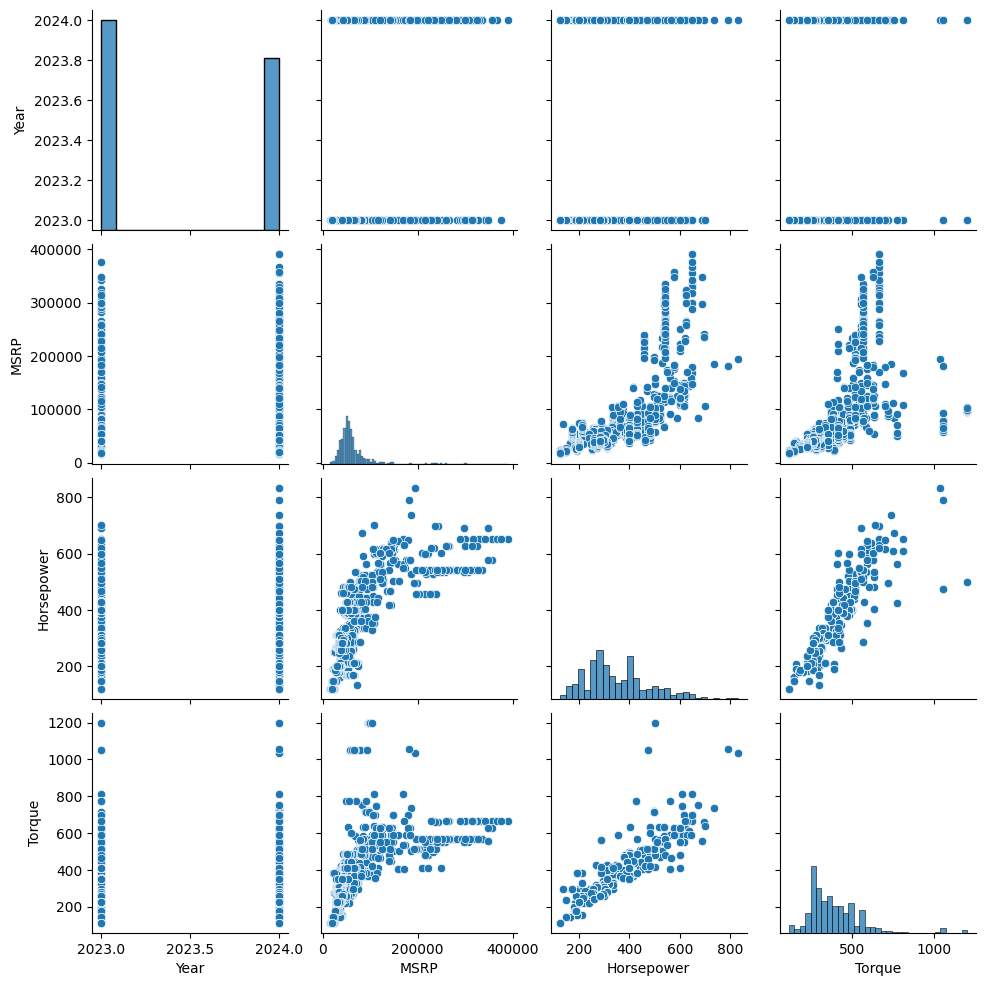

In [31]:
sns.pairplot(df)

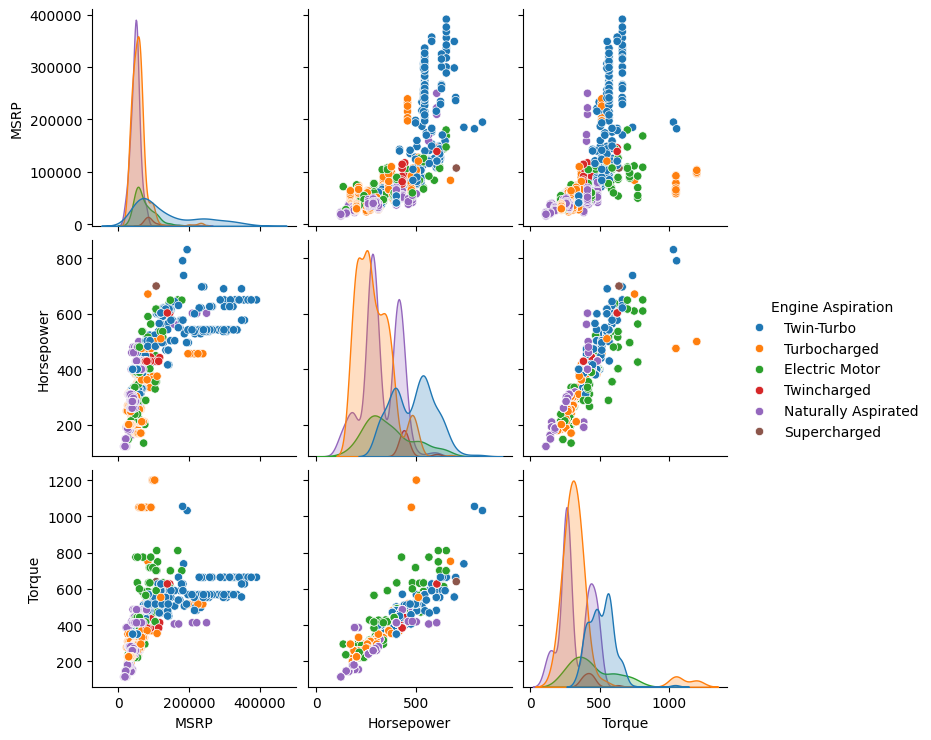

In [34]:
sns.pairplot(df[["MSRP","Horsepower","Torque","Engine Aspiration"]], hue="Engine Aspiration")

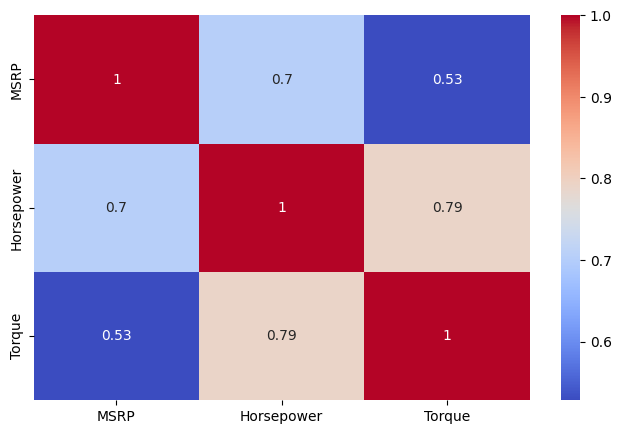

In [54]:

plt.figure(figsize=(8,5))
sns.heatmap(
    df[['MSRP','Horsepower','Torque']].corr(),
    annot= True,
    cmap="coolwarm",
    
           )
plt.show()

#### converting categorical data to numeric

In [45]:
#
df.drop(['Model','Year'], axis=1, inplace=True)
df.columns

Index(['Make', 'MSRP', 'Body Size', 'Body Style', 'Engine Aspiration',
       'Drivetrain', 'Transmission', 'Horsepower', 'Torque'],
      dtype='str')

In [46]:
df = pd.get_dummies(df, columns = ["Make","Body Size","Body Style","Engine Aspiration","Drivetrain","Transmission"])

In [49]:
df.head()

,MSRP,Horsepower,Torque,Make_Aston Martin,Make_Audi,Make_BMW,Make_Bentley,Make_Ford,Make_Mercedes-Benz,Make_Nissan,...,Engine Aspiration_Supercharged,Engine Aspiration_Turbocharged,Engine Aspiration_Twin-Turbo,Engine Aspiration_Twincharged,Drivetrain_4WD,Drivetrain_AWD,Drivetrain_FWD,Drivetrain_RWD,Transmission_automatic,Transmission_manual
0,242000.0,697.0,663.0,True,False,False,False,False,False,False,...,False,False,True,False,False,True,False,False,True,False
1,35800.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False
2,37800.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
3,41400.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,True,False,False,True,False
4,39400.0,201.0,221.0,False,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,True,False


In [48]:
df.isnull().sum()

MSRP                                     0
Horsepower                               0
Torque                                   0
Make_Aston Martin                        0
Make_Audi                                0
Make_BMW                                 0
Make_Bentley                             0
Make_Ford                                0
Make_Mercedes-Benz                       0
Make_Nissan                              0
Body Size_Compact                        0
Body Size_Large                          0
Body Size_Midsize                        0
Body Style_Cargo Minivan                 0
Body Style_Cargo Van                     0
Body Style_Convertible                   0
Body Style_Convertible SUV               0
Body Style_Coupe                         0
Body Style_Hatchback                     0
Body Style_Passenger Minivan             0
Body Style_Passenger Van                 0
Body Style_Pickup Truck                  0
Body Style_SUV                           0
Body Style_

###  Split the data into X & y

In [58]:
X = df.drop(['MSRP'], axis = 1).values
X_columns = df.drop(['MSRP'], axis = 1)
y = df['MSRP'].astype(int)

In [59]:
print(X.shape)
print(y.shape)

(1610, 36)
(1610,)


In [61]:
# Run a Tree-based estimators (i.e. decision trees & random forests)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
dt = DecisionTreeClassifier(random_state=15, criterion = 'entropy', max_depth = 10)
dt.fit(X,y)

C:\Users\icons\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\tree\_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",15
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [63]:
# Calculating FI
for i, column in enumerate(df.drop('MSRP', axis=1)):
    print('Importance of feature {}:, {:.3f}'.format(column, dt.feature_importances_[i]))
    
    fi = pd.DataFrame({'Variable': [column], 'Feature Importance Score': [dt.feature_importances_[i]]})
    
    try:
        final_fi = pd.concat([final_fi,fi], ignore_index = True)
    except:
        final_fi = fi
        
        
# Ordering the data
final_fi = final_fi.sort_values('Feature Importance Score', ascending = False).reset_index()            
final_fi

Importance of feature Horsepower:, 0.244
Importance of feature Torque:, 0.147
Importance of feature Make_Aston Martin:, 0.000
Importance of feature Make_Audi:, 0.023
Importance of feature Make_BMW:, 0.011
Importance of feature Make_Bentley:, 0.013
Importance of feature Make_Ford:, 0.124
Importance of feature Make_Mercedes-Benz:, 0.023
Importance of feature Make_Nissan:, 0.006
Importance of feature Body Size_Compact:, 0.023
Importance of feature Body Size_Large:, 0.043
Importance of feature Body Size_Midsize:, 0.032
Importance of feature Body Style_Cargo Minivan:, 0.000
Importance of feature Body Style_Cargo Van:, 0.024
Importance of feature Body Style_Convertible:, 0.009
Importance of feature Body Style_Convertible SUV:, 0.001
Importance of feature Body Style_Coupe:, 0.007
Importance of feature Body Style_Hatchback:, 0.000
Importance of feature Body Style_Passenger Minivan:, 0.001
Importance of feature Body Style_Passenger Van:, 0.001
Importance of feature Body Style_Pickup Truck:, 0.0

,index,Variable,Feature Importance Score
0,0,Horsepower,0.243534
1,1,Torque,0.147421
2,6,Make_Ford,0.123898
3,27,Engine Aspiration_Turbocharged,0.088182
4,10,Body Size_Large,0.042706
5,21,Body Style_SUV,0.034049
6,11,Body Size_Midsize,0.031797
7,31,Drivetrain_AWD,0.027890
8,30,Drivetrain_4WD,0.027750
9,33,Drivetrain_RWD,0.026684


In [64]:
# Hold-out validation
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80, test_size = 0.2, random_state=15)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1288, 36)
(322, 36)
(1288,)
(322,)


## 6. Running Regression

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error, mean_squared_error
from math import sqrt

lm = LinearRegression(fit_intercept = True)
lm.fit(X_train, y_train)


y_pred = lm.predict(X_train)
all_df_predict = lm.predict(X)

In [69]:
# Model Accuracy on training dataset

print('The Accuracy  on the training dataset is: ', lm.score(X_train, y_train) )
print('The Accuracy r2  on the training dataset prediction is: ',r2_score(y_train,y_pred) )   

print("")
# Model Accuracy on testing dataset
print('The Accuracy  on the testing dataset is: ', lm.score(X_test, y_test) )

print("")
# The Root Mean Squared Error (RMSE)
print('The RMSE  on the training dataset is: ',sqrt(mean_squared_error(y_train,y_pred)))
print('The RMSE  on the testing dataset is: ',sqrt(mean_squared_error(y_test,lm.predict(X_test))))

print("")
# The Mean Absolute Error (MAE)
print('The MAE  on the training dataset is: ',mean_absolute_error(y_train,y_pred))
print('The MAE  on the testing dataset is: ',mean_absolute_error(y_test,lm.predict(X_test)))


print("")
# Coefficients
print('Coefficients: ', lm.coef_ )

print("")
# The Intercept
print('Intercept: ', lm.intercept_)



The Accuracy  on the training dataset is:  0.8953665170418976
The Accuracy r2  on the training dataset prediction is:  0.8953665170418976

The Accuracy  on the testing dataset is:  0.9192331334331458

The RMSE  on the training dataset is:  17456.235463365214
The RMSE  on the testing dataset is:  16599.39863531127

The MAE  on the training dataset is:  10670.135570245218
The MAE  on the testing dataset is:  11243.252908630126

Coefficients:  [ 2.13776153e+02  4.87207171e-02  5.54111683e+04 -2.91460864e+04
 -3.68535732e+04  1.15115427e+05 -4.34875746e+04 -1.70988131e+04
 -4.39405477e+04  3.22123242e+02 -5.22024761e+02  1.99901519e+02
  1.87030411e+03  8.62800638e+03  1.38970770e+04 -9.31257610e+02
  3.36813067e+02 -4.63288883e+03  7.16575055e+03  8.56120559e+03
 -1.81678282e+04 -5.56896544e+03 -3.71202951e+03 -7.44618712e+03
  5.38441611e+03  2.07178754e+03 -1.48762320e+04  1.12834688e+03
  1.03315082e+04 -4.03982678e+03  4.39576662e+03 -3.46527858e+03
  4.89450597e+03 -5.82499401e+03  1

## 7. Storing Our Model & Results

In [74]:
# Storing the ML Model
import pickle
# Storing the ML Model
with open('linear_model.pkl', 'wb') as f:
    pickle.dump(lm, f)

In [75]:
df.columns

Index(['MSRP', 'Horsepower', 'Torque', 'Make_Aston Martin', 'Make_Audi',
       'Make_BMW', 'Make_Bentley', 'Make_Ford', 'Make_Mercedes-Benz',
       'Make_Nissan', 'Body Size_Compact', 'Body Size_Large',
       'Body Size_Midsize', 'Body Style_Cargo Minivan', 'Body Style_Cargo Van',
       'Body Style_Convertible', 'Body Style_Convertible SUV',
       'Body Style_Coupe', 'Body Style_Hatchback',
       'Body Style_Passenger Minivan', 'Body Style_Passenger Van',
       'Body Style_Pickup Truck', 'Body Style_SUV', 'Body Style_Sedan',
       'Body Style_Wagon', 'Engine Aspiration_Electric Motor',
       'Engine Aspiration_Naturally Aspirated',
       'Engine Aspiration_Supercharged', 'Engine Aspiration_Turbocharged',
       'Engine Aspiration_Twin-Turbo', 'Engine Aspiration_Twincharged',
       'Drivetrain_4WD', 'Drivetrain_AWD', 'Drivetrain_FWD', 'Drivetrain_RWD',
       'Transmission_automatic', 'Transmission_manual'],
      dtype='str')

In [76]:
# Storing the Feature Importances
final_fi['Feature Importance Score'] = final_fi['Feature Importance Score'].round(4)
final_fi = final_fi.head(27)
final_fi.to_excel("feature_importance.xlsx")

In [78]:
# Adding the predicted values
df['MSRP Predictions'] = all_df_predict

# Expoprting all the data with predictions
df.to_excel("data_with_pred.xlsx")